# Python Project - Portfolio

This project will focus on presenting some data processing and statistical analisys using python. The dataset file used is available at the "files" folder of this project.

## Company Context & Business Problem

A fictional pharmaceutical company is specialized in anti-cancer pharmaceuticals based on medicines. They provided data to test the effectiveness of potential treatments medications for squamous cell carcinoma. In this study, 100 mice identified with tumor growth of squamous cell carcinoma (SCC), a type of skin cancer, have been treated through a variety of drug regimens. Over 45 days, tumor development was observed and measured. The objective is to analyze the data to show how four treatments (Capomulin, Ramicane, Infubinol and Placebo) compare.

We must answer these 3 questions:

• Business Problem nº1 - **Is there any outlier in tumor volume for each treatment?**

• Business Problem nº2 - **Is there an effect on the tumor over time for one of the medications?**

• Business Problem nº3 - **For one of the medications, what is the relationship between the guinea pig's weight and Tumor Size?**

### Inicial imports that we'll use during the project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

### Load and Initial Analysis of dataset

After the business problem is defined and we have the dataset, the first thing we need to do is load the dataset and get to know it. 

In [2]:
df_pyproj = pd.read_csv("dataset.csv") # Loads the dataset.

In [3]:
df_pyproj.head() # Allows us to have a general view of the dataset.

,ID Mouse,Drug,Sex,Age_month,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
0,m000,Placebo,Male,18,21,0,45.780350,2
1,m000,Ramicane,Male,24,17,5,42.728114,0
2,m000,Ramicane,Female,19,23,10,40.827502,1
3,m000,Capomulin,Female,21,23,15,38.578206,2
4,m000,Infubinol,Male,12,17,20,35.094393,2


In [4]:
df_pyproj.shape # Allows us to quickly know how big is the dataset.

(500, 8)

In [5]:
df_pyproj.info() # Allows us to quickly have information regarding the dataset consistency, format and size.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID Mouse            500 non-null    object 
 1   Drug                500 non-null    object 
 2   Sex                 500 non-null    object 
 3   Age_month           500 non-null    int64  
 4   Weight (g)          500 non-null    int64  
 5   Timepoint           500 non-null    int64  
 6   Tumor Volume (mm3)  500 non-null    float64
 7   Metastatic Sites    500 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 31.4+ KB


## 1. Data Cleaning

As part of any Data Analysis process, we need to check for inconsistencies on the dataset. Thus, the Data cleaning phase is essencial.

In [6]:
df_pyproj.columns # Allows us to quickly check column names.

Index(['ID Mouse', 'Drug', 'Sex', 'Age_month', 'Weight (g)', 'Timepoint',
       'Tumor Volume (mm3)', 'Metastatic Sites'],
      dtype='object')

In [7]:
df_pyproj["ID Mouse"].nunique() # Allows us to see how many different mouses there are in the dataset.

100

In [8]:
df_pyproj.isna().any() # Checks if there is any "N/A" value in each column.

ID Mouse              False
Drug                  False
Sex                   False
Age_month             False
Weight (g)            False
Timepoint             False
Tumor Volume (mm3)    False
Metastatic Sites      False
dtype: bool

In [9]:
print(df_pyproj['Drug'].unique()) # Checks if there is any generic value, such as "Other", "N/A", "empty", etc.
print(df_pyproj['Sex'].unique()) # Checks if there is any generic value, such as "Other", "N/A", "empty", etc.

['Placebo' 'Ramicane' 'Capomulin' 'Infubinol']
['Male' 'Female']


OBS.: No N/A, empty or null value was found. We now should check for duplicated values.

In [10]:
# The code below saves as an array in the variable "duplicate_ID" any
# repeated registry, taking into consideration the mouse ID and
# the Timepoint when the registry was made.
duplicate_ID = df_pyproj.loc[df_pyproj.duplicated(subset = ['ID Mouse', "Timepoint"]), "ID Mouse"].unique()

In [11]:
# As we can see below, the array remains empty, so there's no repeated registry at any time for any mouse.

duplicate_ID

array([], dtype=object)

In [12]:
# If there was any duplicates in the dataset, we could use the code below to clean it from the dataset.

df_pyproj_final = df_pyproj[df_pyproj["ID Mouse"].isin(duplicate_ID) == False]

In [13]:
# Once again, we can see that no line was dropped, so there was no duplicated line found.

df_pyproj_final.shape

(500, 8)

We've checked for null values, any empty or generic data in the dataset, and none was found. We've also checked for duplicated lines or registries, but also with no result. Thus, data can be considered clean.

## 2. Statistic Summary

The statistic summary selects only the numeric columns of the dataset. The code below identifies all columns in the dataset.

In [14]:
# Group data by "Drug" and filter by variable "Tumor Volume (mm3)"
df_pyproj_final_grouped = df_pyproj_final.groupby('Drug')["Tumor Volume (mm3)"]

In [15]:
# With that, we can build a table with statistics regarding each drug and tumor volume.
df_statistic_summary_v2 = df_pyproj_final_grouped.agg(["mean", "median", "var", "std", "sem"])

In [16]:
df_statistic_summary_v2

,mean,median,var,std,sem
Drug,,,,,
Capomulin,39.952874,40.162141,19.485353,4.414222,0.396409
Infubinol,39.527638,39.598429,22.306899,4.723018,0.436643
Placebo,40.204385,40.072851,22.427712,4.735790,0.421898
Ramicane,40.437902,40.682981,16.588849,4.072941,0.353169


These statistics can be a delivery for the research team for their analysis, in case they need it. However, it allows us to better comprehend the dataset and might be usefull in the future to answer the business problems presented to us in the begining of the project. 

## 3. Exploratory Analysis

An initial exploratory analysis was done before for us to compreehend the dataset. However, we'll now dive into further detail onto it, so we can start extracting insights and answering our business problems.

In [17]:
# Counts how many registries we have per Drug

df_pyproj_final["Drug"].value_counts()

Ramicane     133
Placebo      126
Capomulin    124
Infubinol    117
Name: Drug, dtype: int64

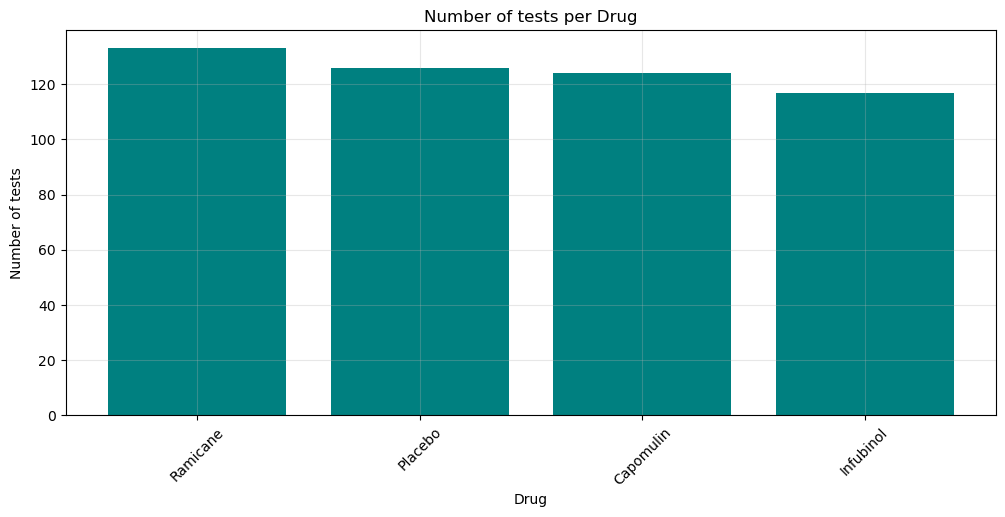

In [18]:
# Quick plotted graph to view how registries per Drug

plt.figure(figsize = (12, 5)) 
x_axis = df_pyproj_final["Drug"].value_counts().index.values
y_axis = df_pyproj_final["Drug"].value_counts().values
plt.bar(x_axis, y_axis, color = "teal")
plt.title("Number of tests per Drug")
plt.xlabel("Drug")
plt.ylabel("Number of tests")
plt.grid(alpha = 0.3)
plt.xticks(rotation = 45)
plt.show()

From the graph generated, we can see that the drugs were tested more or less the same number of times. Let's now check the average tumor volume per age group.

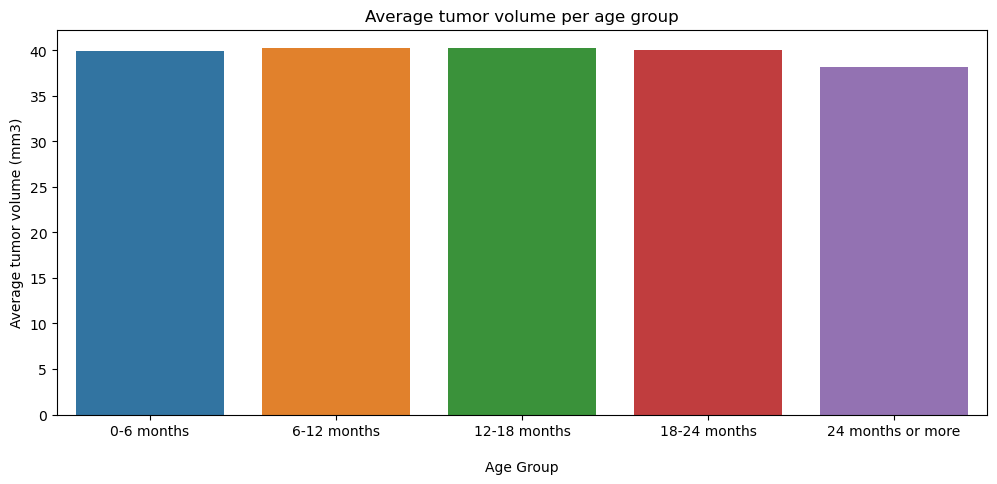

In [19]:
# Calculating Avearage tumor size per age group

# First, we need to define each age group
bins = [0, 6, 12, 18, 24, 30]  
labels = ['0-6 months', '6-12 months', '12-18 months', '18-24 months', '24 months or more']
df_pyproj_final['age_group'] = pd.cut(df_pyproj_final['Age_month'], 
                                      bins = bins, 
                                      labels = labels, 
                                      right = False)

# Now, we'll group by "age_group" and calculate the average of "Tumor Volume (mm3)"
average_tumor = df_pyproj_final.groupby('age_group')['Tumor Volume (mm3)'].mean().reset_index()

# Now, we can plot the graph
import seaborn as sns
plt.figure(figsize = (12, 5)) 
sns.barplot(x = 'age_group', y = 'Tumor Volume (mm3)', data = average_tumor)
plt.title('Average tumor volume per age group')
plt.xlabel('\nAge Group')
plt.ylabel('Average tumor volume (mm3)')
plt.show()

Now we can better see the drugs effect, that seems to have effect only after 24 months of usage.

### Business Problem nº1 - Is there any outlier in tumor volume for each treatment?

To answer this question, we'll make a statistical report that tells us if there's an outlier, as well as a boxplot for each drug. We'll also consider the final tumor size for this (only cases where timepoint was 20)

First, we'll make the report:

In [20]:
# Step 1. Filter data by Drug
Capomulin_df = df_pyproj_final.loc[df_pyproj_final["Drug"] == "Capomulin", :]
Ramicane_df = df_pyproj_final.loc[df_pyproj_final["Drug"] == "Ramicane", :]
Infubinol_df = df_pyproj_final.loc[df_pyproj_final["Drug"] == "Infubinol", :]
Ceftamin_df = df_pyproj_final.loc[df_pyproj_final["Drug"] == "Ceftamin", :]

In [21]:
# Step 2. Extract the last timepoint for each mouse
last_timepoint = pd.DataFrame(df_pyproj_final.groupby('ID Mouse')['Timepoint'].max().sort_values()) \
                    .reset_index().rename(columns = {'Timepoint': 'max_timepoint'})

# Step 3. Add the last timepoint as a column in the original dataframe
merged_df = pd.merge(df_pyproj_final, last_timepoint, on = "ID Mouse")

# Step 4. Group by 'ID Mouse' and obtains the highest value (the lastest treatment from each mouse), filtering 'Timepoint'
Capomulin_last = Capomulin_df.groupby('ID Mouse').max()['Timepoint']

# Step 5. Create empty list for tumor volume and another list with the drugs
tumor_volume = []
list_drugs = ["Capomulin", "Ramicane", "Infubinol", "Placebo"]

In [22]:
print(f"\nStatistic Summary of Outliers")

# Loops through each drug from the list
for drug in list_drugs:

    # Filter the dataframe to obtain only data from the current drug
    df_data = merged_df.loc[merged_df["Drug"] == drug]
    
    # Find tumor volume for last registered timepoint for the current drug
    final_volume = df_data.loc[df_data["Timepoint"] == df_data["max_timepoint"]]
    
    # Select the tumor volume column from filtered data
    final_volumes = final_volume["Tumor Volume (mm3)"]
    
    # Add final volume to the tumor volume list
    tumor_volume.append(final_volumes)
        
    # Calculates each quartile for the final tumor volumes
    quartiles = final_volumes.quantile([0.25,.5,0.75])

    # Associates the first quartile to the variable lowerq
    lowerq = quartiles[0.25]
    
    # Associates the third quartile to the variable upperq
    upperq = quartiles[0.75]
    
    # Calculates interquartile range (IQR)
    iqr = upperq - lowerq
    
    # Calculates lower limit for outlier detection
    lower_bound = lowerq - (1.5 * iqr)
    
    # Calculates upper limit for outlier detection
    upper_bound = upperq + (1.5 * iqr)
    
    # Counts the outliers based on the previously defined limits
    outliers = final_volumes[(final_volume["Tumor Volume (mm3)"] <= lower_bound) | \
                             (final_volume["Tumor Volume (mm3)"] >= upper_bound)].count()

    # Prints the outlier statistic summary for each med
    print(f"\nIQR for {drug}: {iqr}")
    print(f"Lower limit for {drug}: {lower_bound}")
    print(f"Upper limit for {drug}: {upper_bound}")
    print(f"Drug: {drug} -> Number of outliers: {outliers}")


Statistic Summary of Outliers

IQR for Capomulin: 4.852178469471447
Lower limit for Capomulin: 25.767389137683136
Upper limit for Capomulin: 45.17610301556893
Drug: Capomulin -> Number of outliers: 0

IQR for Ramicane: 5.003897167188235
Lower limit for Ramicane: 26.055360480530023
Upper limit for Ramicane: 46.07094914928297
Drug: Ramicane -> Number of outliers: 0

IQR for Infubinol: 3.8793474601479048
Lower limit for Infubinol: 26.74425645494983
Upper limit for Infubinol: 42.26164629554145
Drug: Infubinol -> Number of outliers: 0

IQR for Placebo: 5.16298824225909
Lower limit for Placebo: 24.757630535846673
Upper limit for Placebo: 45.40958350488303
Drug: Placebo -> Number of outliers: 0


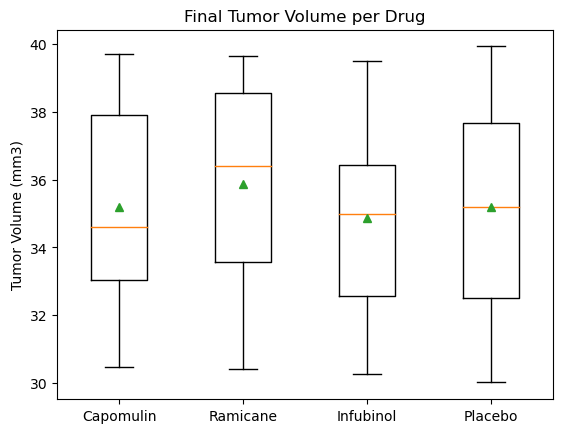

In [23]:
# Plots Boxplot
format = dict(marker = "o")
plt.boxplot(tumor_volume, flierprops = format, showmeans = True)
plt.title("Final Tumor Volume per Drug")
plt.ylabel("Tumor Volume (mm3)")
plt.xticks([1,2,3,4], ["Capomulin", "Ramicane", "Infubinol", "Placebo"])
plt.show()

Answer: There is no outlier in the drug treatment regarding the final tumor volume.

### Business Problem nº2 - Is there an effect on tumor volume over time with the use of the drugs?

To answer this question, we can plot a graph with the average tumor volume through the different timepoints.  With that, we can see the effect of tumor volume over time.

In [24]:
# Extracts data, considering all Drugs except Placebo, grouping them by average on each timepoint.
mouse_treatment = df_pyproj_final.loc[df_pyproj_final['Drug'] != "Placebo"][["Timepoint", "Tumor Volume (mm3)"]].groupby("Timepoint").mean()["Tumor Volume (mm3)"].reset_index()

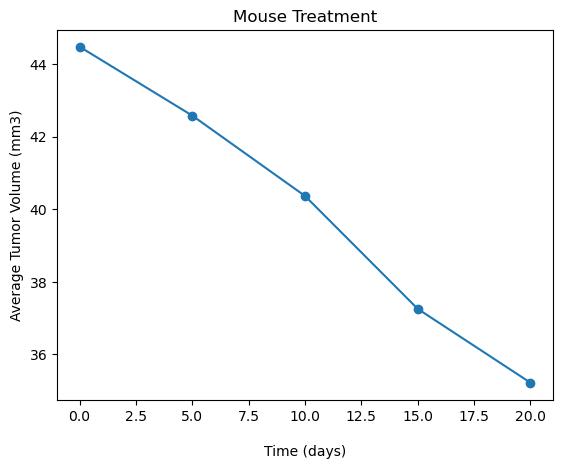

In [25]:
# Plot
plt.plot(mouse_treatment[["Timepoint"]], mouse_treatment[["Tumor Volume (mm3)"]], marker = "o")
plt.xlabel("\nTime (days)")
plt.ylabel("Average Tumor Volume (mm3)")
plt.title("Mouse Treatment")
plt.show()

The average value of tumor size seems to decay across time on the research. Thus, it seems to be an effect on tumor size with the drug administration.
For further investigation, some changes on the research approach will have to happen, such as testing only one drug in each mouse, or using a standardized drug aplication method for us to be able to better compare the results of each drug administration to the Placebo. After that, we should calculate the significance of the results.

### Business Problem nº3 - For each drug, what is the relationship between the weight of the mouse and the size of the tumor?

For this question, we need to analyse (1) each drug, (2) tumor size and (3) Guinea pig Weight. For that, we decided to use the average tumor volume for each drug in each mouse. 

In [26]:
# Filters data
capomulin_treatment = df_pyproj_final.loc[df_pyproj_final["Drug"] == "Capomulin"]
ramicane_treatment = df_pyproj_final.loc[df_pyproj_final["Drug"] == "Ramicane"]
infubinol_treatment = df_pyproj_final.loc[df_pyproj_final["Drug"] == "Infubinol"]

In [27]:
# Now, to answer the question, we'll get the average tumor size for each mouse, and each Drug dataframe.
capomulin_avg_tumor_volume = capomulin_treatment.groupby('ID Mouse')[['Age_month', 
                                                            'Weight (g)', 
                                                            'Timepoint', 
                                                            'Tumor Volume (mm3)', 
                                                            'Metastatic Sites']].mean()
ramicane_avg_tumor_volume = ramicane_treatment.groupby('ID Mouse')[['Age_month', 
                                                            'Weight (g)', 
                                                            'Timepoint', 
                                                            'Tumor Volume (mm3)', 
                                                            'Metastatic Sites']].mean()
infubinol_avg_tumor_volume = infubinol_treatment.groupby('ID Mouse')[['Age_month', 
                                                            'Weight (g)', 
                                                            'Timepoint', 
                                                            'Tumor Volume (mm3)', 
                                                            'Metastatic Sites']].mean()

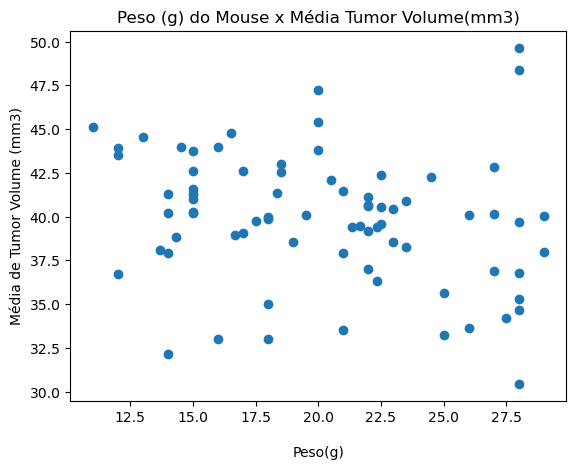

In [28]:
# Plots the Scatter Plot
x_values = capomulin_avg_tumor_volume["Weight (g)"]
y_values = capomulin_avg_tumor_volume["Tumor Volume (mm3)"]
plt.scatter(x_values, y_values)
plt.title("Peso (g) do Mouse x Média Tumor Volume(mm3)")
plt.xlabel("\nPeso(g)")
plt.ylabel("Média de Tumor Volume (mm3)")
plt.show()

For further investigation, we'll calculate the correlation between weight and average tumor volume. Then, we can use that to make a linear regression model.

In [29]:
# Calculates the correlation
capomulin_correlation_model = st.pearsonr(capomulin_avg_tumor_volume["Weight (g)"], capomulin_avg_tumor_volume["Tumor Volume (mm3)"])
ramicane_correlation_model = st.pearsonr(ramicane_avg_tumor_volume["Weight (g)"], ramicane_avg_tumor_volume["Tumor Volume (mm3)"])
infubinol_correlation_model = st.pearsonr(infubinol_avg_tumor_volume["Weight (g)"], infubinol_avg_tumor_volume["Tumor Volume (mm3)"])

print(f"The correlation between Weight (g) and Tumor Volume (mm3) is:\nCapomulin: {round(capomulin_correlation_model[0],2)}\nRamicane:  {round(ramicane_correlation_model[0],2)}\nInfubinol: {round(infubinol_correlation_model[0],2)}")

The correlation between Weight (g) and Tumor Volume (mm3) is:
Capomulin: -0.22
Ramicane:  -0.06
Infubinol: -0.0


In [30]:
# Creates a linear regression model
capomulin_model = st.linregress(capomulin_avg_tumor_volume["Weight (g)"], capomulin_avg_tumor_volume["Tumor Volume (mm3)"])
ramicane_model = st.linregress(ramicane_avg_tumor_volume["Weight (g)"], ramicane_avg_tumor_volume["Tumor Volume (mm3)"])
infubinol_model = st.linregress(infubinol_avg_tumor_volume["Weight (g)"], infubinol_avg_tumor_volume["Tumor Volume (mm3)"])

# Creates the formula for regression with the coeficients found
capomulin_model_formula = capomulin_model.intercept + capomulin_model.slope * capomulin_avg_tumor_volume["Weight (g)"]
ramicane_model_formula = ramicane_model.intercept + ramicane_model.slope * ramicane_avg_tumor_volume["Weight (g)"]
infubinol_model_formula = infubinol_model.intercept + infubinol_model.slope * infubinol_avg_tumor_volume["Weight (g)"]

# Calculates the regression line
capomulin_line_equation = f"y={round(capomulin_model.slope, 2)}x + {round(capomulin_model.intercept, 2)}"
ramicane_line_equation = f"y={round(ramicane_model.slope, 2)}x + {round(ramicane_model.intercept, 2)}"
infubinol_line_equation = f"y={round(infubinol_model.slope, 2)}x + {round(infubinol_model.intercept, 2)}"

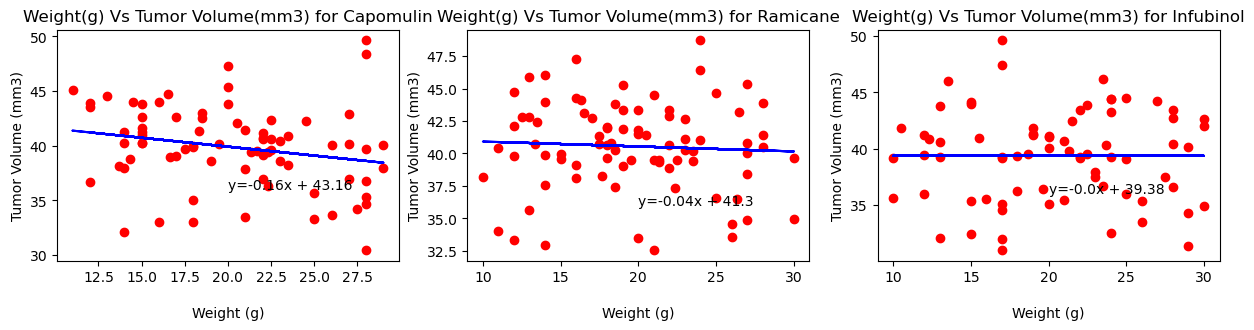

In [31]:
# Plots all three graphs
# Plot
plt.figure(figsize=(15, 3))

plt.subplot(131)
plt.scatter(capomulin_avg_tumor_volume["Weight (g)"], capomulin_avg_tumor_volume["Tumor Volume (mm3)"], color = "r")
plt.plot(capomulin_avg_tumor_volume["Weight (g)"], capomulin_model_formula, color = "blue")
plt.xlabel("\nWeight (g)")
plt.ylabel("Tumor Volume (mm3)")
plt.title("Weight(g) Vs Tumor Volume(mm3) for Capomulin")
plt.annotate(capomulin_line_equation, (20,36))

plt.subplot(132)
plt.scatter(ramicane_avg_tumor_volume["Weight (g)"], ramicane_avg_tumor_volume["Tumor Volume (mm3)"], color = "r")
plt.plot(ramicane_avg_tumor_volume["Weight (g)"], ramicane_model_formula, color = "blue")
plt.xlabel("\nWeight (g)")
plt.ylabel("Tumor Volume (mm3)")
plt.title("Weight(g) Vs Tumor Volume(mm3) for Ramicane")
plt.annotate(ramicane_line_equation, (20,36))

plt.subplot(133)
plt.scatter(infubinol_avg_tumor_volume["Weight (g)"], infubinol_avg_tumor_volume["Tumor Volume (mm3)"], color = "r")
plt.plot(infubinol_avg_tumor_volume["Weight (g)"], infubinol_model_formula, color = "blue")
plt.xlabel("\nWeight (g)")
plt.ylabel("Tumor Volume (mm3)")
plt.title("Weight(g) Vs Tumor Volume(mm3) for Infubinol")
plt.annotate(infubinol_line_equation, (20,36))

plt.show()

Answer: The proximity of all three correlations is next to 0. Thus, it's a weak/null correlation between tumor volume and mouse weight.

## Final considerations

This dataset shows many research inconsistencies and was only used to pratice skills in data processing and statistical analysis. The data used in this project is fictitious.